# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Vina Widiasari
- **Email:** cdcc229d6x0985@student.devacademy.id
- **ID Dicoding:** CDCC229D6X0985

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap rata-rata penyewaan sepeda per hari selama periode 2011-2012?
- Bagaimana perbandingan rata-rata penyewaan sepeda antara hari libur dan hari kerja pada tahun 2011-2012?
- Pada jam berapa saja (minimal 3 jam) yang menjadi puncak dan lembah penyewaan sepeda selama 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
day_df = pd.read_csv('/content/drive/MyDrive/data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
hour_df = pd.read_csv('/content/drive/MyDrive/data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset yang digunakan merupakan data historis penyewaan sepeda dari sistem Capital Bikeshare di Washington D.C., USA selama periode 2011–2012.
- Data disajikan dalam dua tingkat granularitas, yaitu harian (day.csv) dan per jam (hour.csv), sehingga memungkinkan analisis baik secara makro maupun detail.
- Jumlah observasi terdiri dari 731 data harian dan 17.379 data per jam.
- Dataset ini tidak hanya memuat jumlah penyewaan sepeda (cnt), tetapi juga faktor-faktor yang berpotensi memengaruhi permintaan, seperti:
  - Kondisi cuaca (weathersit, temp, hum, windspeed)
  - Waktu (yr, mnth, weekday, hr)
  - Kondisi kalender (holiday, workingday, season)
- Variabel cnt merupakan jumlah total penyewaan yang merupakan agregasi dari dua tipe pengguna, yaitu casual dan registered.
- Nilai pada beberapa variabel seperti temp, atemp, hum, dan windspeed telah dinormalisasi, sehingga perlu diperhatikan dalam interpretasi analisis.

### Assessing Data

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Dataset harian (731 data) dan dataset per jam (17.379 data) tidak memiliki missing values, sehingga data tergolong lengkap untuk dianalisis.
- Kolom dteday masih bertipe object dan perlu dikonversi menjadi datetime, serta beberapa variabel, yaitu season, weathersit, holiday, dan workingday masih berupa numerik meskipun bersifat kategorikal.
- Jumlah penyewaan sepeda (cnt) memiliki variasi yang tinggi, baik pada tingkat harian (22–8714) maupun per jam (1–977), yang menunjukkan fluktuasi penggunaan yang signifikan.
- Pengguna registered jauh lebih dominan dibandingkan casual, yang mengindikasikan bahwa layanan lebih banyak digunakan untuk kebutuhan rutin.
- Terdapat inkonsistensi antara dataset harian dan per jam, khususnya pada variabel weathersit, di mana kondisi cuaca ekstrem hanya muncul pada data per jam.
- Ditemukan nilai yang tidak umum, seperti registered = 0 dan hum = 0, yang mengindikasikan potensi anomali atau hasil preprocessing pada data.
- Variabel waktu disajikan dalam beberapa bentuk (dteday, yr, mnth, weekday), sehingga berpotensi menimbulkan redundansi informasi dalam analisis lanjutan.
- Tingginya variabilitas data menunjukkan bahwa analisis berbasis waktu (time series) relevan untuk dilakukan pada tahap berikutnya.

### Cleaning Data

In [ ]:
# Konversi kolom tanggal ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Konversi variabel kategorikal dari numerik ke tipe category
categorical_cols = ['season', 'yr', 'mnth', 'weekday', 'weathersit', 'holiday', 'workingday']
for col in categorical_cols:
    day_df[col] = day_df[col].astype('category')
    hour_df[col] = hour_df[col].astype('category')

# Drop kolom indeks yang tidak digunakan
day_df.drop(columns=['instant'], inplace=True)
hour_df.drop(columns=['instant'], inplace=True)

In [ ]:
print("Jumlah hum = 0 (day_df): ", (day_df['hum'] == 0).sum())
print("Jumlah hum = 0 (hour_df): ", (hour_df['hum'] == 0).sum())

Jumlah hum = 0 (day_df):  1
Jumlah hum = 0 (hour_df):  22


In [ ]:
day_df = day_df[day_df['hum'] > 0]
print("Jumlah hum = 0 (day_df): ", (day_df['hum'] == 0).sum())
hour_df = hour_df[hour_df['hum'] > 0]
print("Jumlah hum = 0 (hour_df): ", (hour_df['hum'] == 0).sum())

Jumlah hum = 0 (day_df):  0
Jumlah hum = 0 (hour_df):  0


In [ ]:
print(f"Day DF Match: {(day_df.cnt == day_df.casual + day_df.registered).all()}")
print(f"Hour DF Match: {(hour_df.cnt == hour_df.casual + hour_df.registered).all()}")

Day DF Match: True
Hour DF Match: True


In [ ]:
print("Rentang jam:", hour_df['hr'].min(),"-", hour_df['hr'].max())

Rentang jam: 0 - 23


In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 730 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      730 non-null    datetime64[ns]
 1   season      730 non-null    category      
 2   yr          730 non-null    category      
 3   mnth        730 non-null    category      
 4   holiday     730 non-null    category      
 5   weekday     730 non-null    category      
 6   workingday  730 non-null    category      
 7   weathersit  730 non-null    category      
 8   temp        730 non-null    float64       
 9   atemp       730 non-null    float64       
 10  hum         730 non-null    float64       
 11  windspeed   730 non-null    float64       
 12  casual      730 non-null    int64         
 13  registered  730 non-null    int64         
 14  cnt         730 non-null    int64         
dtypes: category(7), datetime64[ns](1), float64(4), int64(3)
memory usage: 57.7 KB


In [ ]:
day_df.describe()

,dteday,temp,atemp,hum,windspeed,casual,registered,cnt
count,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,2012-01-01 09:45:51.780822016,0.495530,0.474475,0.628754,0.190388,849.275342,3660.390411,4509.665753
min,2011-01-01 00:00:00,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,2011-07-03 06:00:00,0.336875,0.337794,0.520521,0.134950,316.250000,2502.250000,3169.750000
50%,2012-01-01 12:00:00,0.499167,0.487364,0.627083,0.180971,717.000000,3664.500000,4548.500000
75%,2012-07-01 18:00:00,0.655625,0.608916,0.730313,0.233207,1096.500000,4783.250000,5966.000000
max,2012-12-31 00:00:00,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,NaN,0.183134,0.163040,0.140614,0.077506,686.449738,1557.149836,1933.194931


In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17357 entries, 0 to 17378
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17357 non-null  datetime64[ns]
 1   season      17357 non-null  category      
 2   yr          17357 non-null  category      
 3   mnth        17357 non-null  category      
 4   hr          17357 non-null  int64         
 5   holiday     17357 non-null  category      
 6   weekday     17357 non-null  category      
 7   workingday  17357 non-null  category      
 8   weathersit  17357 non-null  category      
 9   temp        17357 non-null  float64       
 10  atemp       17357 non-null  float64       
 11  hum         17357 non-null  float64       
 12  windspeed   17357 non-null  float64       
 13  casual      17357 non-null  int64         
 14  registered  17357 non-null  int64         
 15  cnt         17357 non-null  int64         
dtypes: category(7), datetime64[

In [ ]:
hour_df.describe()

,dteday,hr,temp,atemp,hum,windspeed,casual,registered,cnt
count,17357,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000
mean,2012-01-02 13:12:48.035950848,11.545889,0.497124,0.475889,0.628024,0.190007,35.718788,153.948551,189.667339
min,2011-01-01 00:00:00,0.000000,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-05 00:00:00,6.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,2012-01-03 00:00:00,12.000000,0.500000,0.484800,0.630000,0.194000,17.000000,116.000000,142.000000
75%,2012-07-02 00:00:00,18.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 00:00:00,23.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,NaN,6.914537,0.192635,0.171921,0.191754,0.122342,49.321693,151.382189,181.409297


**Insight:**
- Tidak ditemukan missing values pada kedua dataset, sehingga tidak diperlukan penanganan nilai kosong.
- Kolom dteday berhasil dikonversi menjadi tipe datetime untuk mendukung analisis berbasis waktu.
- Variabel seperti season, yr, mnth, weathersit, holiday, weekday, dan workingday telah diubah menjadi tipe kategorikal agar sesuai dengan karakteristik data dan menghindari kesalahan interpretasi sebagai numerik.
- Kolom instant dihapus karena tidak memberikan informasi yang relevan untuk analisis.
- Ditemukan nilai anomali pada variabel hum sebesar 0 sebanyak 22 data (0,13%), yang dianggap tidak realistis sehingga data tersebut dihapus.
- Tidak ditemukan inkonsistensi pada data, dibuktikan dengan kesesuaian antara cnt dengan penjumlahan casual dan registered.
- Variabel hr berada dalam rentang yang valid (0–23), sehingga tidak ditemukan kesalahan pada data waktu.

## Exploratory Data Analysis (EDA)

### Explore Data day_df

In [ ]:
weather_labels = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
day_df['weather_label'] = day_df['weathersit'].map(weather_labels)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_labels)

In [ ]:
weather_daily = (
    day_df
    .groupby('weather_label')['cnt']
    .agg(mean_cnt='mean', median_cnt='median', min_cnt='min', max_cnt='max', n='count')
    .reset_index()
    .sort_values('mean_cnt', ascending=False)
)
weather_daily

/tmp/ipykernel_8472/2346371856.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('weather_label')['cnt']


,weather_label,mean_cnt,median_cnt,min_cnt,max_cnt,n
0,Clear,4876.786177,4844.0,431,8714,463
1,Mist/Cloudy,4035.862348,4040.0,605,8362,247
2,Light Rain/Snow,1862.300000,1829.5,22,4639,20


In [ ]:
day_df['temp_bin'] = pd.qcut(day_df['temp'], q=4)  # kuartil

temp_effect = (
    day_df
    .groupby('temp_bin')['cnt']
    .mean()
    .reset_index()
    .sort_values('temp_bin')
)
temp_effect

/tmp/ipykernel_8472/1343490087.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('temp_bin')['cnt']


,temp_bin,cnt
0,"(0.0581, 0.337]",2615.076503
1,"(0.337, 0.499]",4206.148352
2,"(0.499, 0.656]",5591.104396
3,"(0.656, 0.862]",5630.584699


In [ ]:
day_df['hum_bin'] = pd.qcut(day_df['hum'], q=4)

hum_effect = (
    day_df
    .groupby('hum_bin')['cnt']
    .mean()
    .reset_index()
    .sort_values('hum_bin')
)
hum_effect

/tmp/ipykernel_8472/154428161.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('hum_bin')['cnt']


,hum_bin,cnt
0,"(0.187, 0.521]",4398.327869
1,"(0.521, 0.627]",4851.703297
2,"(0.627, 0.73]",4913.571429
3,"(0.73, 0.972]",3879.136612


In [ ]:
day_df['wind_bin'] = pd.qcut(day_df['windspeed'], q=4)

wind_effect = (
    day_df
    .groupby('wind_bin')['cnt']
    .mean()
    .reset_index()
    .sort_values('wind_bin')
)
wind_effect

/tmp/ipykernel_8472/2141517236.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('wind_bin')['cnt']


,wind_bin,cnt
0,"(0.0214, 0.135]",4922.934783
1,"(0.135, 0.181]",4934.646409
2,"(0.181, 0.233]",4186.269231
3,"(0.233, 0.507]",3995.431694


In [ ]:
corr_weather = day_df[['cnt','temp','hum','windspeed']].corr()
corr_weather

,cnt,temp,hum,windspeed
cnt,1.000000,0.627774,-0.114625,-0.232790
temp,0.627774,1.000000,0.125160,-0.157338
hum,-0.114625,0.125160,1.000000,-0.246366
windspeed,-0.232790,-0.157338,-0.246366,1.000000


**Insight:**
- Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda, di mana cuaca yang lebih baik menghasilkan tingkat penyewaan yang lebih tinggi.
- Rata-rata penyewaan tertinggi terjadi pada kondisi cuaca cerah, menurun pada kondisi berawan, dan turun drastis pada kondisi hujan atau salju ringan.
- Variabel suhu (temp) menunjukkan korelasi positif cukup kuat (0.627) terhadap jumlah penyewaan, yang mengindikasikan bahwa suhu yang lebih tinggi mendorong peningkatan penggunaan sepeda.
- Analisis berbasis kelompok menunjukkan bahwa semakin tinggi suhu, rata-rata penyewaan cenderung meningkat secara konsisten.
- Variabel kelembapan (hum) memiliki korelasi negatif lemah (-0.115), dengan pola bahwa penyewaan cenderung meningkat pada tingkat kelembapan menengah dan menurun pada kelembapan yang terlalu tinggi.
- Variabel kecepatan angin (windspeed) juga menunjukkan korelasi negatif (-0.233), yang mengindikasikan bahwa angin yang lebih kencang cenderung mengurangi minat penggunaan sepeda.
- Dibandingkan variabel lainnya, suhu merupakan faktor cuaca yang paling dominan, sedangkan kelembapan dan kecepatan angin memiliki pengaruh yang lebih kecil.
- Secara keseluruhan, kondisi yang mendukung peningkatan penyewaan sepeda adalah suhu yang lebih hangat, kelembapan pada tingkat menengah, dan kecepatan angin yang rendah.

### Explore Data hour_df

In [ ]:
hourly_working = (
    hour_df
    .groupby(['workingday','hr'])['cnt']
    .mean()
    .reset_index()
)
hourly_working

/tmp/ipykernel_8472/3050457228.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['workingday','hr'])['cnt']


,workingday,hr,cnt
0,0,0,90.800000
1,0,1,69.508696
2,0,2,53.171053
3,0,3,25.775330
4,0,4,8.264317
5,0,5,8.689189
6,0,6,18.742358
7,0,7,43.406926
8,0,8,105.653680
9,0,9,171.623377


In [ ]:
weekday_data = hourly_working[hourly_working['workingday'] == 1]
weekday_sorted = weekday_data.sort_values(by='cnt', ascending=False)

weekday_sorted

,workingday,hr,cnt
41,1,17,526.122490
42,1,18,493.052314
32,1,8,477.880808
43,1,19,348.989940
40,1,16,293.668675
31,1,7,291.125253
44,1,20,250.144869
33,1,9,241.957576
39,1,15,201.708249
36,1,12,201.157258


In [ ]:
weekend_data = hourly_working[hourly_working['workingday'] == 0]
weekend_sorted = weekend_data.sort_values(by='cnt', ascending=False)

weekend_sorted

,workingday,hr,cnt
13,0,13,372.731602
12,0,12,366.259740
14,0,14,364.645022
15,0,15,358.813853
16,0,16,352.727273
17,0,17,323.549784
11,0,11,315.316017
18,0,18,281.056522
10,0,10,255.909091
19,0,19,231.673913


In [ ]:
hourly_mean = (
    hour_df
    .groupby('hr')['cnt']
    .mean()
    .reset_index()
    .sort_values('cnt', ascending=False)
)
hourly_mean

,hr,cnt
17,17,461.932785
18,18,425.983494
8,8,359.444904
16,16,312.382716
19,19,311.874828
13,13,253.993132
12,12,253.617607
15,15,251.559066
14,14,241.263736
20,20,226.288858


In [ ]:
peak_hour = hourly_mean.iloc[0]
lowest_hour = hourly_mean.iloc[-1]

print(f"Peak Hour (Jam Tertinggi):")
print(f"Jam: {int(peak_hour['hr'])}")
print(f"Rata-rata Penyewaan: {peak_hour['cnt']:.2f}")

print(f"\nLowest Hour (Jam Terendah):")
print(f"Jam: {int(lowest_hour['hr'])}")
print(f"Rata-rata Penyewaan: {lowest_hour['cnt']:.2f}")

Peak Hour (Jam Tertinggi):
Jam: 17
Rata-rata Penyewaan: 461.93

Lowest Hour (Jam Terendah):
Jam: 4
Rata-rata Penyewaan: 6.35


**Explore Data (Final Preparation)**

In [ ]:
day_df['temp_c'] = day_df['temp'] * 41
day_df['atemp_c'] = day_df['atemp'] * 50
day_df['hum_percent'] = day_df['hum'] * 100
day_df['windspeed_real'] = day_df['windspeed'] * 67

In [ ]:
hour_df['temp_c'] = hour_df['temp'] * 41
hour_df['atemp_c'] = hour_df['atemp'] * 50
hour_df['hum_percent'] = hour_df['hum'] * 100
hour_df['windspeed_real'] = hour_df['windspeed'] * 67

In [ ]:
hour_df['day_type'] = hour_df['workingday'].map({
    0: 'Weekend',
    1: 'Weekday'
})

In [ ]:
hour_df['usage_category'] = pd.cut(
    hour_df['cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

In [ ]:
month_map = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}

weekday_map = {
    0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'
}

hour_df['month_label'] = hour_df['mnth'].map(month_map)
hour_df['weekday_label'] = hour_df['weekday'].map(weekday_map)

In [ ]:
hour_df['season_label'] = hour_df['season'].map({
    1:'Springer',2:'Summer',3:'Fall',4:'Winter'
})

In [ ]:
hour_df['year'] = hour_df['yr'].map({0:2011, 1:2012})

In [ ]:
def categorize_hour(hr):
    if 5 <= hr < 12:
        return 'Morning'
    elif 12 <= hr < 17:
        return 'Afternoon'
    elif 17 <= hr < 21:
        return 'Evening'
    else:
        return 'Night'

hour_df['time_of_day'] = hour_df['hr'].apply(categorize_hour)

**Insight:**
- Rata-rata penyewaan sepeda tertinggi terjadi pada pukul 17.00 dengan rata-rata sekitar 461,93 penyewaan, yang menunjukkan adanya lonjakan penggunaan pada jam pulang kerja (evening rush hour).
- Rata-rata penyewaan terendah terjadi pada pukul 04.00 dengan rata-rata sekitar 6,35 penyewaan, yang mengindikasikan aktivitas penggunaan sepeda sangat rendah pada dini hari.
- Pada hari kerja (workingday), puncak penyewaan juga terjadi pada pukul 17.00 dengan rata-rata lebih tinggi, yaitu sekitar 526,12 penyewaan, yang menunjukkan dominasi penggunaan untuk kebutuhan komuter (berangkat/pulang kerja).
- Pada hari libur (weekday), puncak penyewaan terjadi pada pukul 13.00 dengan rata-rata sekitar 372,73 penyewaan, yang mengindikasikan pola penggunaan yang lebih santai dan cenderung terjadi pada siang hari.
- Secara keseluruhan, rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur, yang menunjukkan bahwa layanan bike sharing lebih banyak dimanfaatkan untuk aktivitas rutin dibandingkan rekreasi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap rata-rata penyewaan sepeda per hari selama periode 2011-2012?

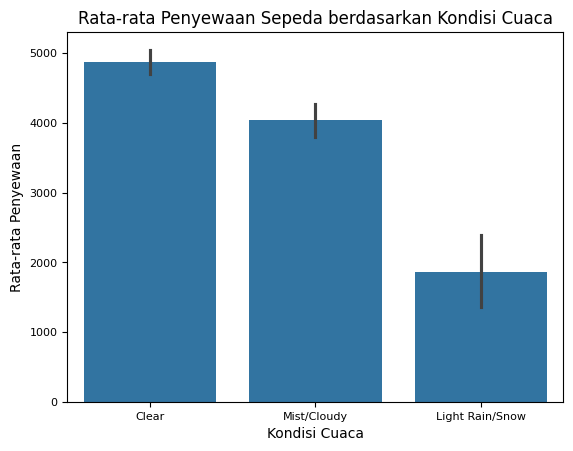

In [ ]:
sns.barplot(data=day_df, x='weather_label', y='cnt')
plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.show()

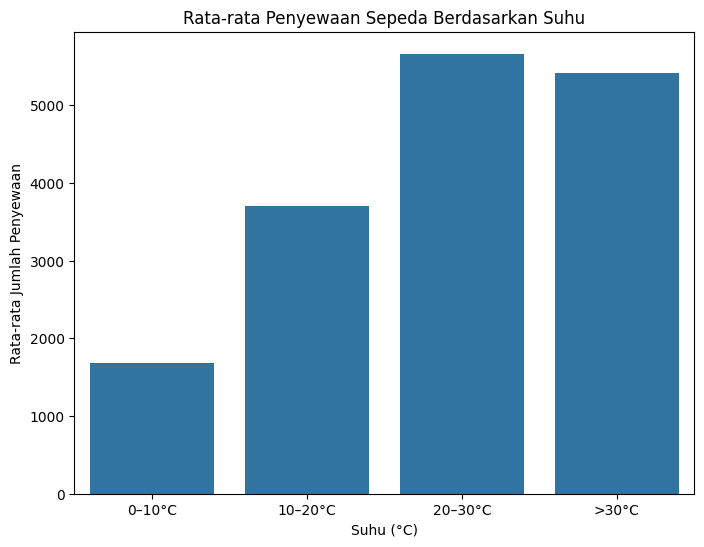

In [ ]:
# Membuat kategori suhu
day_df['temp_group'] = pd.cut(
    day_df['temp_c'],
    bins=[0, 10, 20, 30, 40],
    labels=['0–10°C', '10–20°C', '20–30°C', '>30°C'],
    include_lowest=True
)

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=day_df,
    x='temp_group',
    y='cnt',
    errorbar=None
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Suhu')
plt.xlabel('Suhu (°C)')
plt.ylabel('Rata-rata Jumlah Penyewaan')

plt.show()

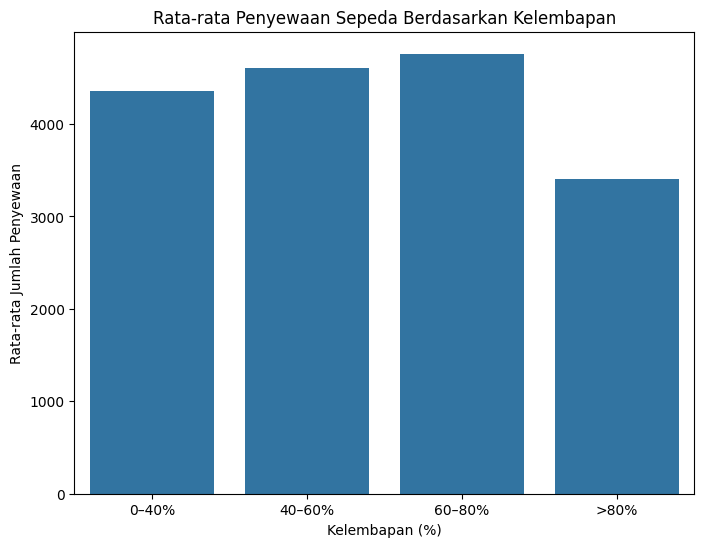

In [ ]:
# Membuat kategori kelembapan
day_df['hum_group'] = pd.cut(
    day_df['hum_percent'],
    bins=[0, 40, 60, 80, 100],
    labels=['0–40%', '40–60%', '60–80%', '>80%'],
    include_lowest=True
)

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=day_df,
    x='hum_group',
    y='cnt',
    errorbar=None
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kelembapan')
plt.xlabel('Kelembapan (%)')
plt.ylabel('Rata-rata Jumlah Penyewaan')

plt.show()

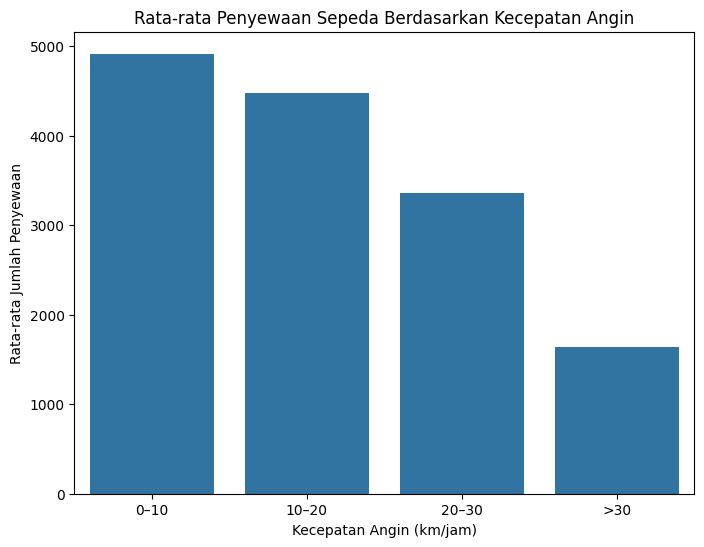

In [ ]:
# Membuat kategori kecepatan angin
day_df['windspeed_group'] = pd.cut(
    day_df['windspeed_real'],
    bins=[0, 10, 20, 30, 40],
    labels=['0–10', '10–20', '20–30', '>30'],
    include_lowest=True
)

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=day_df,
    x='windspeed_group',
    y='cnt',
    errorbar=None
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kecepatan Angin')
plt.xlabel('Kecepatan Angin (km/jam)')
plt.ylabel('Rata-rata Jumlah Penyewaan')

plt.show()

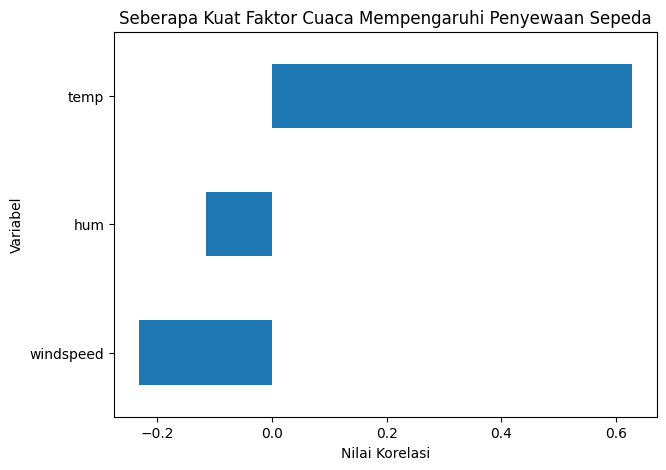

In [ ]:
# Ambil korelasi terhadap target (cnt)
corr_vals = day_df[['cnt','temp','hum','windspeed']]\
    .corr(numeric_only=True)['cnt']\
    .drop('cnt')\
    .sort_values()

# Plot
plt.figure(figsize=(7,5))
corr_vals.plot(kind='barh')

plt.title('Seberapa Kuat Faktor Cuaca Mempengaruhi Penyewaan Sepeda')
plt.xlabel('Nilai Korelasi')
plt.ylabel('Variabel')

plt.show()

### Pertanyaan 2: Bagaimana perbandingan rata-rata penyewaan sepeda antara hari libur dan hari kerja pada tahun 2011-2012?

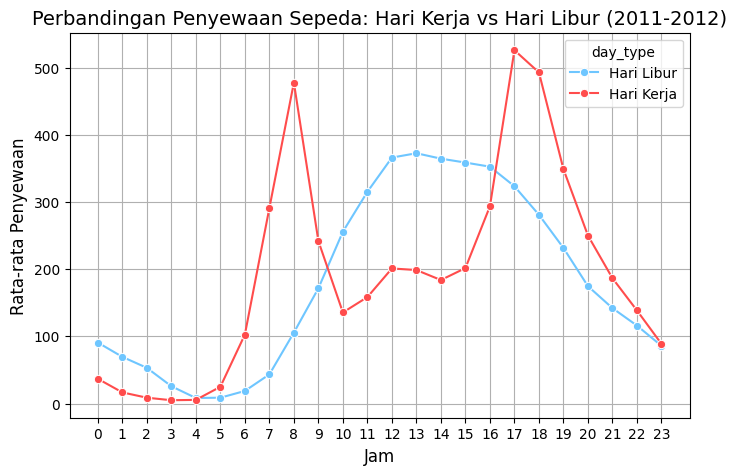

In [ ]:
hourly_working['day_type'] = hourly_working['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})

plt.figure(figsize=(8,5))

sns.lineplot(data=hourly_working, x='hr', y='cnt', hue='day_type',
             marker='o', palette={'Hari Libur': '#6EC6FF', 'Hari Kerja': '#FF4C4C'})

plt.title('Perbandingan Penyewaan Sepeda: Hari Kerja vs Hari Libur (2011-2012)', fontsize=14)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

/tmp/ipykernel_8472/3157139798.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('workingday')['cnt']
/tmp/ipykernel_8472/3157139798.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


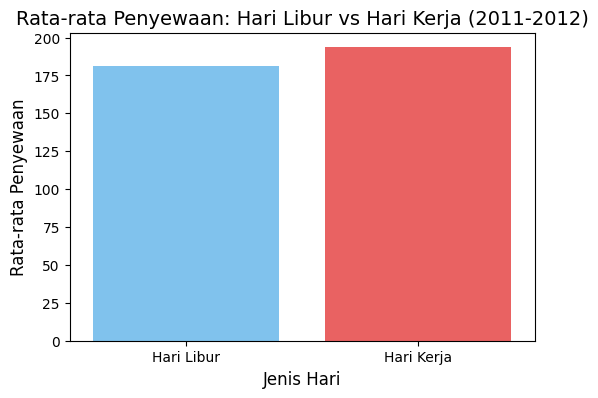

In [ ]:
avg_comparison = (
    hour_df
    .groupby('workingday')['cnt']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=avg_comparison,
    x='workingday',
    y='cnt',
    palette=['#6EC6FF', '#FF4C4C']
)

plt.title('Rata-rata Penyewaan: Hari Libur vs Hari Kerja (2011-2012)', fontsize=14)
plt.xlabel('Jenis Hari', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)

plt.xticks([0,1], ['Hari Libur', 'Hari Kerja'])

plt.show()

/tmp/ipykernel_8472/2525874635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='day_type', y='cnt',


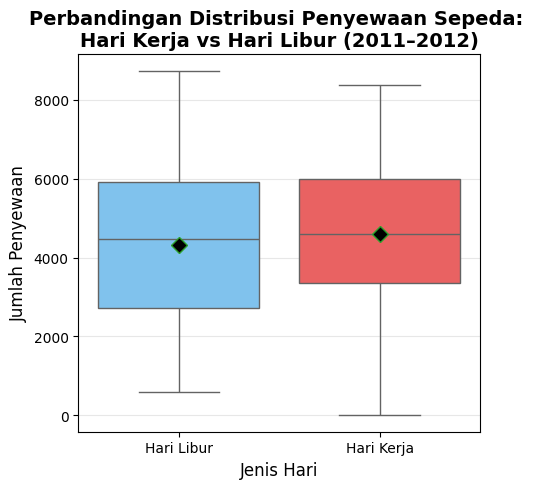

In [ ]:
day_df['day_type'] = day_df['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})
plt.figure(figsize=(5,5))

sns.boxplot(data=day_df, x='day_type', y='cnt',
            palette=['#6EC6FF', '#FF4C4C'],
            showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 8})

plt.title('Perbandingan Distribusi Penyewaan Sepeda: \nHari Kerja vs Hari Libur (2011–2012)',
          fontsize=14, fontweight='bold')
plt.xlabel('Jenis Hari', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Pertanyaan 3: Pada jam berapa saja (minimal 3 jam) yang menjadi puncak dan lembah penyewaan sepeda selama 2011-2012?




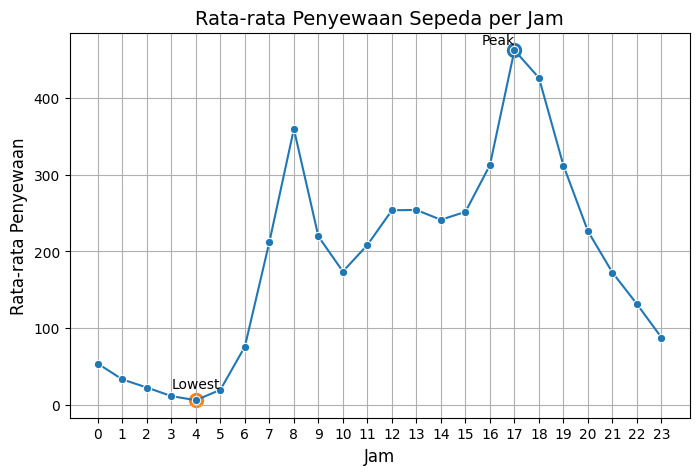

In [ ]:
hourly_mean_sorted = hourly_mean.sort_values('hr')

plt.figure(figsize=(8,5))

sns.lineplot(data=hourly_mean_sorted, x='hr', y='cnt', marker='o')

plt.title('Rata-rata Penyewaan Sepeda per Jam', fontsize=14)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)

plt.scatter(peak_hour['hr'], peak_hour['cnt'], s=100)
plt.text(peak_hour['hr'], peak_hour['cnt']+8, 'Peak', ha='right')

plt.scatter(lowest_hour['hr'], lowest_hour['cnt'], s=100)
plt.text(lowest_hour['hr'], lowest_hour['cnt']+15, 'Lowest', ha='center')

plt.xticks(range(0,24))
plt.grid(True)

plt.show()

/tmp/ipykernel_8472/2210020921.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8472/2210020921.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


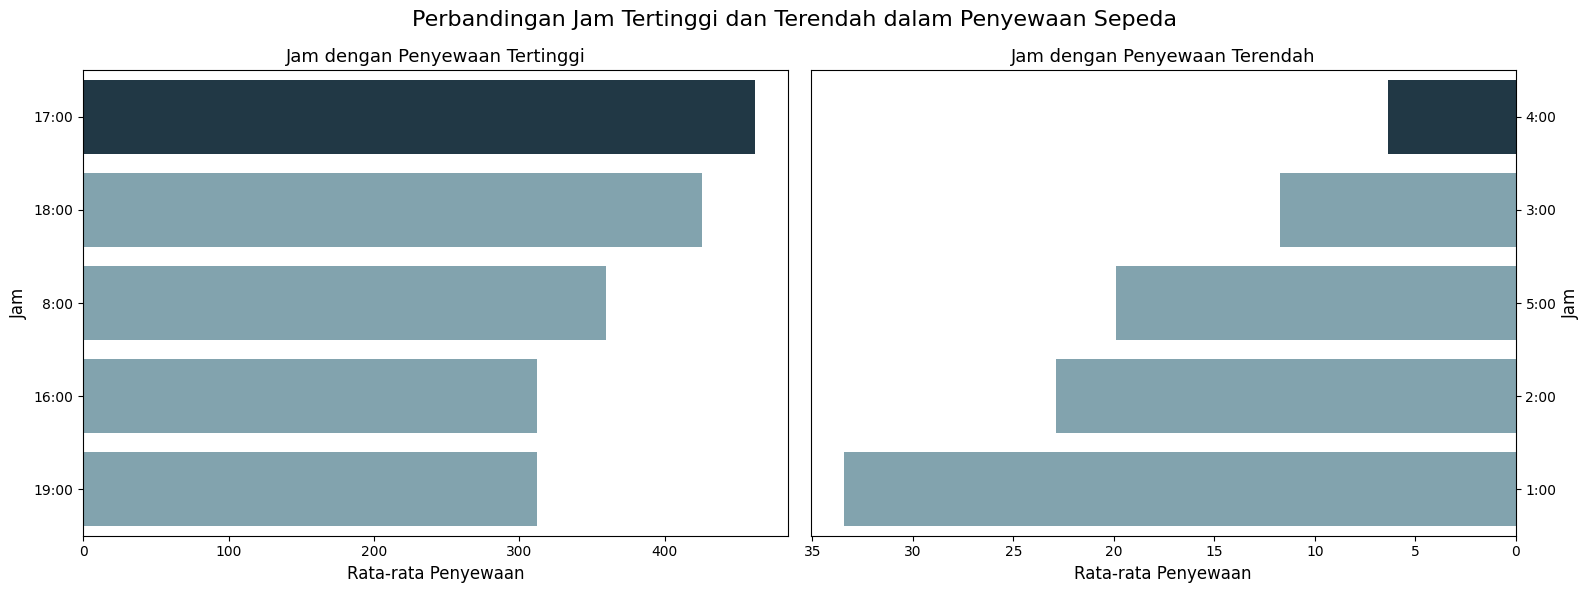

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

hourly_mean['hr'] = hourly_mean['hr'].astype(int).astype(str) + ":00"
top5 = hourly_mean.sort_values(by='cnt', ascending=False).head(5)
bottom5 = hourly_mean.sort_values(by='cnt', ascending=True).head(5)

colors = ["#1B3A4B"] + ["#7BA6B5"] * 4

# Top 5
sns.barplot(
    x="cnt",
    y="hr",
    data=top5.sort_values(by="cnt", ascending=False),
    palette=colors,
    ax=ax[0]
)
ax[0].set_title("Jam dengan Penyewaan Tertinggi", fontsize=13)
ax[0].set_ylabel("Jam", fontsize=12)
ax[0].set_xlabel("Rata-rata Penyewaan", fontsize=12)

# Bottom 5
sns.barplot(
    x="cnt",
    y="hr",
    data=bottom5.sort_values(by="cnt", ascending=True),
    palette=colors,
    ax=ax[1]
)
ax[1].set_title("Jam dengan Penyewaan Terendah", fontsize=13)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_ylabel("Jam", fontsize=12)
ax[1].set_xlabel("Rata-rata Penyewaan", fontsize=12)

plt.suptitle("Perbandingan Jam Tertinggi dan Terendah dalam Penyewaan Sepeda", fontsize=16)
plt.tight_layout()
plt.show()

**Insight:**
1. **Pengaruh kondisi cuaca terhadap penyewaan sepeda**
- Penyewaan tertinggi terjadi pada kondisi cuaca cerah (Clear), kemudian menurun pada kondisi berawan (Mist/Cloudy), dan paling rendah saat hujan atau salju ringan. Hal ini menunjukkan bahwa kondisi cuaca yang lebih baik secara langsung mendorong peningkatan penggunaan sepeda.
- Suhu memiliki pengaruh paling dominan, di mana rata-rata penyewaan meningkat seiring dengan kenaikan suhu. Secara khusus, rata-rata penyewaan tertinggi terjadi pada rentang suhu 20–30°C, yang menunjukkan bahwa kondisi suhu hangat merupakan kondisi paling optimal untuk penggunaan sepeda.
- Kelembapan menunjukkan kecenderungan negatif, di mana kategori dengan tingkat kelembapan lebih tinggi memiliki rata-rata penyewaan yang lebih rendah dibandingkan kelembapan sedang atau rendah. Di mana rata-rata jumlah penyewaan tertinggi terjadi pada kategori kelembapan 60-80%, kemudian menurun pada kategori 40-60% dan 0-40%, serta mencapai rata-rata terendah pada kelembapan >80%.
- Kecepatan angin juga berpengaruh negatif, terlihat bahwa semakin tinggi kecepatan angin, rata-rata penyewaan cenderung menurun. Kategori kecepatan angin 0–10 km/jam memiliki rata-rata penyewaan tertinggi, sementara kategori >30 km/jam memiliki rata-rata terendah.
- Secara keseluruhan, pola pada bar chart memperlihatkan bahwa:
  - Suhu : faktor utama yang meningkatkan penyewaan
  - Kelembapan & angin : faktor yang menurunkan penyewaan, meskipun pengaruhnya tidak sekuat faktor suhu

2. **Perbandingan hari kerja vs hari libur**
- Rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur, yang menunjukkan dominasi penggunaan untuk aktivitas rutin seperti bekerja atau sekolah.
- Pola penyewaan pada hari kerja membentuk dua puncak tajam : pagi (jam 7–9) dan sore (jam 16–18), mencerminkan mobilitas komuter berangkat dan pulang.
- Pada hari libur, pola penyewaan cenderung lebih landai dan terpusat pada siang hari-sore hari (jam 11-16), menunjukkan penggunaan untuk aktivitas rekreasi.
- Boxplot menunjukkan bahwa distribusi penyewaan pada hari kerja memiliki nilai tengah (median) yang lebih tinggi, meskipun variasi data pada kedua jenis hari cukup besar.
- Secara umum, penyewaan sepeda pada hari kerja lebih konsisten dan tinggi, sedangkan pada hari libur lebih fleksibel dan bergantung pada waktu luang pengguna.

3. **Waktu dengan penyewaan tertinggi dan terendah**
- Rata-rata penyewaan sepeda tertinggi terjadi pada pukul 17.00, diikuti oleh pukul 18.00 dan 08.00, menunjukkan puncak penggunaan pada jam pulang kerja dan berangkat kerja.
- Rata-rata penyewaan sepeda terendah terjadi pada pukul 04.00, yang menunjukkan aktivitas penggunaan sangat rendah pada dini hari.
- Pola penyewaan per jam membentuk tren yang jelas, yaitu:
  - meningkat mulai pagi hari
  - mencapai puncak pada sore hari
  - menurun kembali pada malam hingga dini hari
- Pada malam hari, penyewaan terus menurun setelah jam 19.00 hingga mencapai titik terendah di jam 04.00, lalu mulai naik kembali menjelang pagi.
- Visualisasi barplot mengonfirmasi bahwa jam 17.00 memiliki rata-rata penyewaan tertinggi (> 400) dan jam 04.00 terendah (< 10), dengan selisih yang sangat signifikan.
- Pola ini konsisten di kedua jenis grafik (line dan bar), mencerminkan ritme harian masyarakat: penggunaan tinggi pada jam produktif (pagi dan sore) dan sangat rendah pada jam istirahat malam hingga dini hari.

## Analisis Lanjutan (Opsional)

In [ ]:
hourly_mean_sorted['usage_category'] = pd.cut(
    hourly_mean_sorted['cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

hourly_mean_sorted

,hr,cnt,usage_category
0,0,53.968276,Low
1,1,33.419087,Low
2,2,22.900560,Low
3,3,11.727403,Low
4,4,6.352941,Low
5,5,19.913408,Low
6,6,76.132597,Low
7,7,212.305785,Medium
8,8,359.444904,High
9,9,219.578512,Medium


/tmp/ipykernel_8472/619086757.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


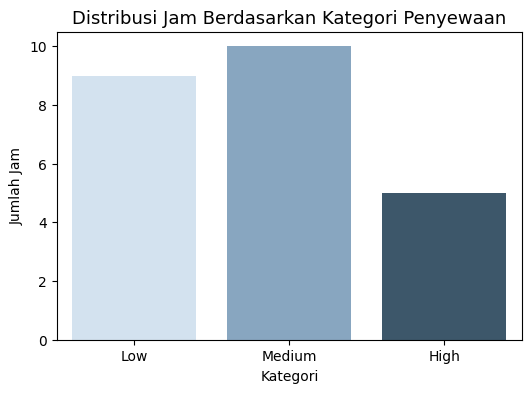

In [ ]:
usage_count = hourly_mean_sorted['usage_category'].value_counts().reset_index()
usage_count.columns = ['usage_category', 'total_hours']

plt.figure(figsize=(6,4))

sns.barplot(
    data=usage_count,
    x='usage_category',
    y='total_hours',
    order=['Low', 'Medium', 'High'],
    palette=['#CFE2F3', '#7FA7C9', '#355872']
)

plt.title('Distribusi Jam Berdasarkan Kategori Penyewaan', fontsize=13)
plt.xlabel('Kategori')
plt.ylabel('Jumlah Jam')

plt.show()

/tmp/ipykernel_8472/2106796798.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


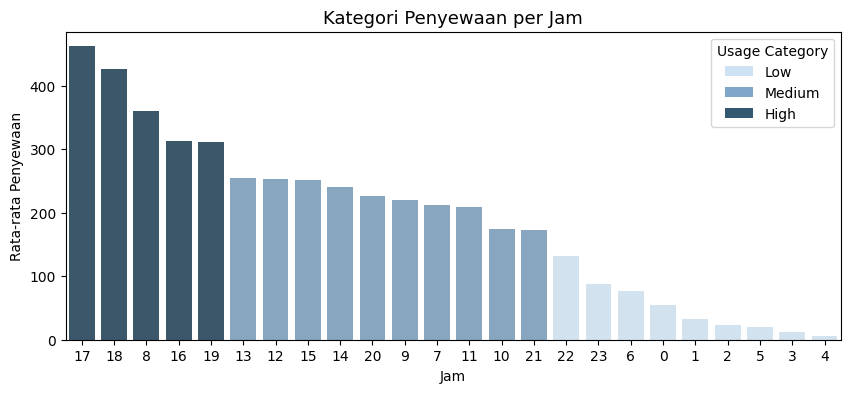

In [ ]:
colors = {
    'Low': '#CFE2F3',
    'Medium': '#7FA7C9',
    'High': '#355872'
}

order_hr = hourly_mean_sorted.sort_values(by='cnt', ascending=False)['hr']

plt.figure(figsize=(10,4))

sns.barplot(
    data=hourly_mean_sorted,
    x='hr',
    y='cnt',
    order=order_hr,
    palette=[colors[val] for val in hourly_mean_sorted.sort_values(by='cnt', ascending=False)['usage_category']]
)

legend_elements = [
    Patch(facecolor='#CFE2F3', label='Low'),
    Patch(facecolor='#7FA7C9', label='Medium'),
    Patch(facecolor='#355872', label='High')
]

plt.legend(handles=legend_elements, title='Usage Category')

plt.title('Kategori Penyewaan per Jam', fontsize=13)
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

Analisis ini dilakukan dengan mengelompokkan rata-rata jumlah penyewaan sepeda per jam (cnt) ke dalam tiga kategori, yaitu Low, Medium, dan High menggunakan metode pd.cut(). Tujuan utama dari pendekatan ini adalah sebagai berikut:

1. Menyederhanakan Data Numerik

    Nilai rata-rata penyewaan per jam berupa data kontinu yang cukup sulit untuk diinterpretasikan secara cepat. Dengan mengelompokkan nilai tersebut ke dalam kategori diskrit, informasi menjadi lebih ringkas dan mudah dipahami, terutama dalam konteks visualisasi.
2. Mengidentifikasi Pola Permintaan Berdasarkan Waktu

    Kategorisasi memungkinkan identifikasi yang lebih jelas terhadap:
    - Jam dengan tingkat permintaan tinggi (peak hours)
    - Jam dengan tingkat permintaan rendah (off-peak hours)
    Sehingga pola aktivitas pengguna sepanjang hari dapat dianalisis dengan lebih sistematis.
3. Mendukung Interpretasi Visual yang Lebih Informatif
    
    Dengan adanya kategori, visualisasi seperti bar chart dapat diperkaya dengan warna yang merepresentasikan tingkat penggunaan. Hal ini membantu pengguna dashboard dalam menangkap insight secara cepat tanpa harus membaca nilai numerik secara detail.
4. Menganalisis Perilaku Pengguna
    
    Klasifikasi ini membantu dalam memahami karakteristik penggunaan sepeda, misalnya:
    - Kategori High cenderung terjadi pada jam sibuk (pagi dan sore) yang berkaitan dengan aktivitas komuter
    - Kategori Low umumnya terjadi pada dini hari saat aktivitas masyarakat rendah
5. Mendukung Pengambilan Keputusan
    
    Hasil kategorisasi dapat digunakan sebagai dasar dalam:
    - Pengelolaan distribusi sepeda (menambah unit pada jam dengan kategori High)
    - Penjadwalan perawatan (maintenance) pada jam dengan kategori Low
    - Perancangan strategi promosi pada periode dengan permintaan rendah

In [ ]:
weather_daily['usage_category'] = pd.cut(
    weather_daily['mean_cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

weather_daily

,weather_label,mean_cnt,median_cnt,min_cnt,max_cnt,n,usage_category
0,Clear,4876.786177,4844.0,431,8714,463,High
1,Mist/Cloudy,4035.862348,4040.0,605,8362,247,High
2,Light Rain/Snow,1862.300000,1829.5,22,4639,20,Low


/tmp/ipykernel_8472/3812447613.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


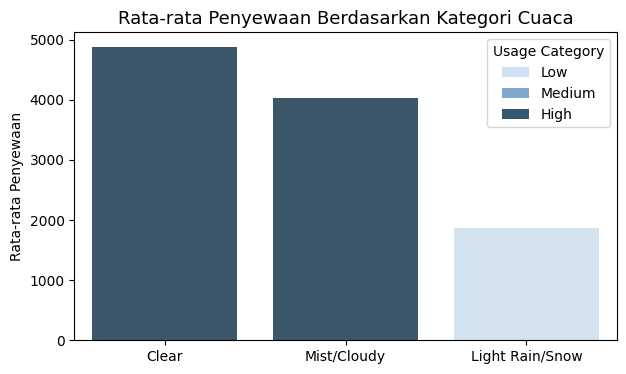

In [ ]:
colors = {
    'Low': '#CFE2F3',
    'Medium': '#7FA7C9',
    'High': '#355872'
}

# urutkan
weather_sorted = weather_daily.sort_values(by='mean_cnt', ascending=False)

plt.figure(figsize=(7,4))

sns.barplot(
    data=weather_sorted,
    x='weather_label',
    y='mean_cnt',
    order=weather_sorted['weather_label'],
    palette=[colors[val] for val in weather_sorted['usage_category']]
)

legend_elements = [
    Patch(facecolor='#CFE2F3', label='Low'),
    Patch(facecolor='#7FA7C9', label='Medium'),
    Patch(facecolor='#355872', label='High')
]

plt.legend(handles=legend_elements, title='Usage Category')

plt.title('Rata-rata Penyewaan Berdasarkan Kategori Cuaca', fontsize=13)
plt.xlabel('')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

Analisis ini dilakukan dengan mengelompokkan rata-rata jumlah penyewaan sepeda berdasarkan kondisi cuaca (mean_cnt) ke dalam tiga kategori, yaitu Low, Medium, dan High menggunakan metode pd.cut(). Tujuan dari pendekatan ini adalah sebagai berikut:

1. Menyederhanakan Interpretasi Pengaruh Cuaca

    Nilai rata-rata penyewaan pada setiap kondisi cuaca bersifat numerik dan relatif sulit dibandingkan secara cepat. Dengan mengubahnya menjadi kategori, perbedaan pengaruh antar kondisi cuaca dapat dipahami dengan lebih intuitif.

2. Mengidentifikasi Tingkat Dampak Cuaca terhadap Penyewaan

    Kategorisasi ini membantu dalam mengelompokkan kondisi cuaca berdasarkan tingkat pengaruhnya terhadap penyewaan:
    - High: kondisi cuaca yang paling mendukung aktivitas bersepeda
    - Medium: kondisi cuaca yang masih memungkinkan aktivitas
    - Low: kondisi cuaca yang cenderung menghambat penyewaan
3. Memperjelas Pola dalam Visualisasi

    Dengan adanya kategori, visualisasi (misalnya bar chart) dapat diberi warna berbeda sesuai tingkat kategori. Hal ini meningkatkan keterbacaan dan mempercepat pemahaman pola tanpa harus fokus pada angka.

4. Mendukung Analisis Perilaku Pengguna terhadap Lingkungan

    Analisis ini memberikan gambaran bagaimana pengguna merespons perubahan kondisi lingkungan, khususnya cuaca. Misalnya:
    - Penyewaan tinggi pada cuaca cerah menunjukkan preferensi terhadap kondisi yang nyaman
    - Penyewaan rendah pada cuaca buruk menunjukkan sensitivitas terhadap faktor eksternal
5. Mendukung Pengambilan Keputusan Operasional

    Hasil kategorisasi dapat dimanfaatkan untuk:
    - Perencanaan jumlah sepeda yang disediakan berdasarkan prediksi cuaca
    - Penyesuaian strategi operasional pada kondisi cuaca tertentu
    - Pengembangan strategi promosi saat kondisi cuaca kurang mendukung

In [ ]:
day_df['temp_category'] = pd.cut(
    day_df['temp_c'],
    bins=[0,15,25,35],
    labels=['Low','Medium','High']
)

temp_cluster = (
    day_df
    .groupby('temp_category', observed=True)['cnt']
    .mean()
    .reset_index()
    .sort_values('temp_category')
)

temp_cluster

,temp_category,cnt
0,Low,2833.316742
1,Medium,4879.835206
2,High,5635.423237


/tmp/ipykernel_8472/258364105.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


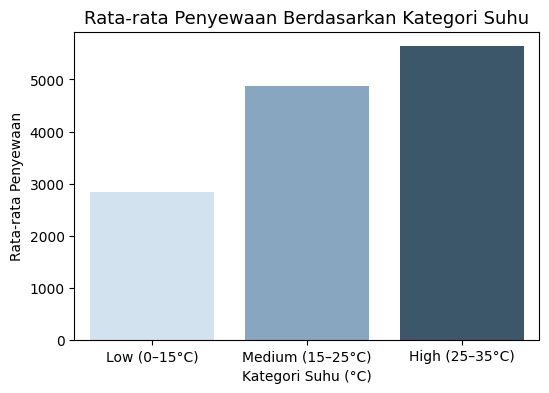

In [ ]:
colors = {
    'Low': '#CFE2F3',
    'Medium': '#7FA7C9',
    'High': '#355872'
}

label_map = {
    'Low': 'Low (0–15°C)',
    'Medium': 'Medium (15–25°C)',
    'High': 'High (25–35°C)'
}

temp_cluster['temp_label'] = temp_cluster['temp_category'].map(label_map)

plt.figure(figsize=(6,4))
sns.barplot(
    data=temp_cluster,
    x='temp_label',
    y='cnt',
    order=['Low (0–15°C)','Medium (15–25°C)','High (25–35°C)'],
    palette=[colors[val] for val in temp_cluster['temp_category']]
)

plt.title('Rata-rata Penyewaan Berdasarkan Kategori Suhu', fontsize=13)
plt.xlabel('Kategori Suhu (°C)')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

Analisis ini dilakukan dengan mengelompokkan suhu udara (temp_c) ke dalam tiga kategori, yaitu Low (0–15°C), Medium (15–25°C), dan High (25–35°C), kemudian menghitung rata-rata jumlah penyewaan sepeda (cnt) pada masing-masing kategori. Tujuan dari analisis ini adalah sebagai berikut:

1. Mengidentifikasi Hubungan Suhu dengan Penyewaan Sepeda

    Pengelompokan suhu memungkinkan analisis hubungan antara kondisi temperatur dengan tingkat penyewaan. Dengan demikian, dapat diketahui pada rentang suhu berapa aktivitas penyewaan paling optimal.

2. Menyederhanakan Interpretasi Variabel Kontinu

    Suhu merupakan variabel kontinu yang memiliki banyak nilai variasi. Dengan mengelompokkannya ke dalam interval tertentu, interpretasi menjadi lebih sederhana dan mudah dibandingkan menganalisis nilai suhu secara individual.

3. Menentukan Rentang Suhu Optimal

    Melalui perhitungan rata-rata penyewaan pada tiap kategori suhu, dapat diidentifikasi:
    - Rentang suhu yang paling mendukung aktivitas bersepeda
    - Rentang suhu yang kurang diminati pengguna

    Hal ini penting untuk memahami preferensi pengguna terhadap kondisi lingkungan.

4. Mendukung Visualisasi yang Lebih Informatif

    Hasil kategorisasi dapat divisualisasikan dalam bentuk bar chart yang menunjukkan perbandingan rata-rata penyewaan pada tiap kategori suhu. Dengan demikian, pola hubungan dapat terlihat secara jelas.

5. Analisis Perilaku Pengguna terhadap Kondisi Lingkungan

    Analisis ini membantu memahami bagaimana perubahan suhu memengaruhi keputusan pengguna dalam menyewa sepeda. Misalnya:

    - Suhu sedang cenderung meningkatkan kenyamanan → penyewaan lebih tinggi
    - Suhu terlalu rendah atau terlalu tinggi dapat menurunkan minat pengguna

6. Mendukung Pengambilan Keputusan

    Hasil analisis dapat digunakan untuk:
    - Perencanaan operasional berbasis kondisi suhu
    - Penyesuaian strategi layanan pada kondisi ekstrem (terlalu panas/dingin)
    - Optimalisasi ketersediaan sepeda pada kondisi suhu tertentu

In [ ]:
season_df = hour_df.groupby('season_label')['cnt'].mean().reset_index()
season_df = season_df.sort_values(by='cnt', ascending=False)
season_df

/tmp/ipykernel_8472/1804388946.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_df = hour_df.groupby('season_label')['cnt'].mean().reset_index()


,season_label,cnt
2,Fall,236.016237
1,Summer,208.344069
3,Winter,198.868856
0,Springer,111.546209


/tmp/ipykernel_8472/158120549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


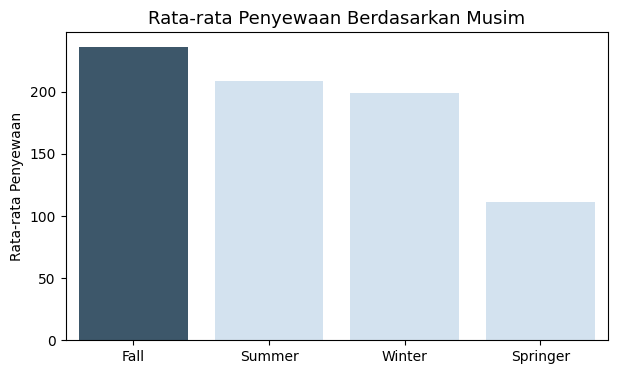

In [ ]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=season_df,
    x='season_label',
    y='cnt',
    order=season_df['season_label'],  # sudah urut dari tertinggi
    palette=['#355872'] + ['#CFE2F3']*(len(season_df)-1)
)

plt.title('Rata-rata Penyewaan Berdasarkan Musim', fontsize=13)
plt.xlabel('')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

Analisis ini dilakukan dengan menghitung rata-rata jumlah penyewaan sepeda (cnt) untuk setiap kategori musim (season_label), kemudian mengurutkannya dari yang tertinggi ke terendah. Tujuan dari analisis ini adalah sebagai berikut:

1. Mengidentifikasi Pengaruh Musim terhadap Penyewaan

    Analisis ini bertujuan untuk mengetahui bagaimana perubahan musim memengaruhi tingkat penyewaan sepeda. Dengan membandingkan rata-rata penyewaan pada tiap musim, dapat terlihat musim mana yang paling mendukung aktivitas bersepeda.

2. Membandingkan Tingkat Permintaan Antar Musim

    Dengan mengurutkan data berdasarkan nilai rata-rata penyewaan, analisis ini memudahkan dalam:
    - Menentukan musim dengan permintaan tertinggi
    - Menentukan musim dengan permintaan terendah
    
    Sehingga perbandingan antar musim menjadi lebih jelas dan sistematis.

3. Mengungkap Pola Musiman (Seasonality)

    Data yang dikelompokkan berdasarkan musim memungkinkan identifikasi pola musiman dalam penggunaan sepeda. Misalnya:
    - Musim dengan cuaca lebih nyaman cenderung memiliki tingkat penyewaan lebih tinggi
    - Musim dengan kondisi ekstrem cenderung menurunkan aktivitas pengguna
4. Mendukung Visualisasi yang Lebih Informatif

    Hasil agregasi ini dapat divisualisasikan dalam bentuk bar chart, sehingga perbedaan rata-rata penyewaan antar musim dapat diamati dengan lebih jelas dan intuitif.

5. Mendukung Analisis Perilaku Pengguna

    Analisis ini memberikan insight mengenai preferensi pengguna terhadap kondisi lingkungan dalam jangka waktu yang lebih panjang (musiman), berbeda dengan analisis per jam atau harian.

6. Mendukung Pengambilan Keputusan Strategis

    Informasi mengenai pola musiman dapat dimanfaatkan untuk:
    - Perencanaan jumlah armada sepeda berdasarkan musim
    - Penyesuaian strategi operasional dan promosi
    - Antisipasi penurunan atau peningkatan permintaan pada periode tertentu

In [ ]:
main_data = hour_df.copy()
main_data.to_csv("main_data.csv", index=False)

## Conclusion

- **Conclution pertanyaan 1 : Bagaimana pengaruh kondisi cuaca terhadap rata-rata penyewaan sepeda per hari selama periode 2011-2012?**
  
  - Cuaca cerah (clear) dan berawan ringan (mist/cloudy) menjadi kondisi paling mendukung penyewaan sepeda, dengan rata-rata penyewaan tertinggi terjadi pada kategori suhu 20-30°C, kelembapan 60-80%, dan kecepatan angin 0-10 km/jam.
  - Cuaca buruk (light rain/snow) menurunkan penyewaan secara drastis, dengan rata-rata terendah pada suhu 0-10°C, kelembapan >80% dan kecepatan angin >30 km/jam.
  - Suhu merupakan faktor dominan: semakin tinggi suhu, semakin tinggi penyewaan.

  - Kelembapan dan kecepatan angin berpengaruh negatif terhadap penyewaan, di mana peningkatan keduanya menurunkan jumlah penyewaan secara konsisten.
  
  **Action Item:**
  - Tambah ketersediaan sepeda pada hari dengan prakiraan cuaca cerah, suhu tinggi (20-30°C), kelembapan 40-80%, dan kecepatan angin < 10 km/jam.
  - Kurangi distribusi sepeda hingga 30-40% saat prakiraan cuaca buruk (light rain/snow, suhu <10°C, kelembapan >80%, kecepatan angin >20 km/jam) untuk menghindari biaya operasional menganggur.
  - Lakukan perawatan sepeda (maintenance) pada hari dengan cuaca buruk, karena permintaan rendah, sehingga tidak mengganggu jam sibuk.
- **Conclution pertanyaan 2 : Bagaimana perbandingan rata-rata penyewaan sepeda antara hari libur dan hari kerja pada tahun 2011-2012?**
  
  - Rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur, yang menunjukkan bahwa layanan bike sharing lebih banyak dimanfaatkan untuk aktivitas rutin, seperti mobilitas kerja atau sekolah.
  - Pola hari kerja: Terdapat dua puncak penyewaan yang jelas dan tajam, yaitu pada jam 7–9 (pagi hari) dan jam 16–18 (sore hari), yang mencerminkan mobilitas komuter saat berangkat dan pulang kerja atau sekolah.
  - Pola hari libur: Penyewaan cenderung membentuk satu puncak yang lebih landai, terjadi pada rentang jam 11–16 (siang hingga sore), yang menunjukkan penggunaan untuk aktivitas rekreasi, olahraga, atau bersantai.
  - Median penyewaan hari kerja lebih tinggi dari hari libur (berdasarkan boxplot), artinya sebagian besar hari kerja memiliki volume penyewaan yang baik secara konsisten.
  - Setelah jam 20.00, penyewaan hari kerja turun drastis, sedangkan hari libur penurunannya lebih bertahap.

  **Action Item:**
  - Hari kerja (Senin–Jumat):
    - Tambah ketersediaan sepeda +40% pada jam 06.30–09.00 dan 16.00–18.30.
    - Siapkan tim operasional untuk redistribusi cepat dari stasiun tujuan rendah (perumahan) ke stasiun tujuan tinggi (kantor/sekolah) pada jam tersebut.
    - Kurangi stok sepeda setelah jam 20.00 dan alihkan ke persiapan untuk pagi hari berikutnya.

  - Hari libur (Sabtu–Minggu & hari libur nasional):
    - Tambah ketersediaan sepeda +20% pada jam 09.00–16.00 di lokasi wisata, taman kota, dan pusat kuliner.
    - Luncurkan promosi "Weekend Ride" (diskon 15% untuk penyewaan >2 jam pada siang hari) untuk mendorong penggunaan rekreasi.
    - Kurangi alokasi sepeda di kawasan perkantoran pada hari libur, alihkan ke area rekreasi.

- **Conclution pertanyaan 3 : Pada jam berapa saja (minimal 3 jam) yang menjadi puncak dan lembah penyewaan sepeda selama 2011-2012?**
  
  - Rata-rata penyewaan tertinggi terjadi pada pukul 17.00, diikuti pukul 18.00, dan pukul 08.00. Hal ini menunjukkan puncak utama pada sore hari (jam pulang kerja) dan puncak sekunder pada pagi hari (jam berangkat kerja).
  - Rata-rata penyewaan terendah terjadi pada pukul 04.00, diikuti pukul 03.00, dan pukul 05.00. Pada rentang jam 02.00–05.00, hampir tidak ada aktivitas penyewaan.
  - Pada hari kerja, kedua puncak (08.00 dan 17.00) lebih tinggi dan tajam. Pada hari libur, puncak lebih landai dan bergeser ke siang (sekitar jam 12.00–14.00).

  **Action Item:**
  - Jam puncak (17.00, 18.00, 08.00):
    - Pastikan 100% sepeda tersedia dan sudah terdistribusi ke stasiun-stasiun padat penduduk (perumahan) pada jam 16.00 (untuk puncak sore) dan jam 06.00 (untuk puncak pagi).
    - Tambah petugas lapangan di stasiun tersibuk pada jam tersebut untuk membantu pengguna dan mempercepat transaksi.
    - Lakukan redistribusi sepeda kosong ke stasiun tinggi permintaan setiap 30 menit pada rentang jam 16.30–18.30.

  - Jam rendah (03.00–05.00):
    - Jadwalkan 100% kegiatan maintenance, servis, dan pengisian baterai (jika e-bike) pada jam ini.
    - Lakukan redistribusi besar-besaran dari stasiun tujuan akhir (kantor, pusat kota) ke stasiun asal (perumahan, stasiun kereta) untuk persiapan pagi hari.
    - Tidak perlu petugas operasional di lapangan, cukup tim gudang dan bengkel.
